# Big Mart Sales Prediction - Data Analysis Pipeline

Este notebook implementa um pipeline completo de análise exploratória, tratamento de dados ausentes e preparação de features para predição de vendas em lojas Big Mart.

## Objetivo
Desenvolver um modelo preditivo robusto para prever as vendas de produtos (`OutletSales`) em diferentes lojas, considerando características do produto, loja e localização.

## 1. Importação de Bibliotecas

As bibliotecas essenciais para análise exploratória, processamento de dados e modelagem de machine learning são importadas abaixo.

In [1]:
#importando
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

## 2. Carregamento e Exploração Inicial dos Dados

O arquivo de treinamento é carregado em um DataFrame Pandas. As primeiras e últimas linhas são examinadas para entender a estrutura dos dados.

In [ ]:
#banco de dados
big_mart = pd.read_csv("db/Train-Set.csv")
pd.concat([big_mart.head(10), big_mart.tail(10)])

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType,OutletSales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


## 3. Dimensões e Informações do Dataset

Verificamos as dimensões do dataset (número de linhas e colunas) para entender o tamanho da base de dados. Em seguida, examinamos o tipo de dados de cada coluna, a quantidade de não-nulos e alocação de memória. Isso ajuda a identificar potenciais problemas como valores ausentes e tipos de dados inadequados.

In [3]:
#linhas por coluna
big_mart.shape

(8523, 12)

In [4]:
#Obtendo algumas informações sobre o conjunto de dados
big_mart.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ProductID          8523 non-null   str    
 1   Weight             7060 non-null   float64
 2   FatContent         8523 non-null   str    
 3   ProductVisibility  8523 non-null   float64
 4   ProductType        8523 non-null   str    
 5   MRP                8523 non-null   float64
 6   OutletID           8523 non-null   str    
 7   EstablishmentYear  8523 non-null   int64  
 8   OutletSize         6113 non-null   str    
 9   LocationType       8523 non-null   str    
 10  OutletType         8523 non-null   str    
 11  OutletSales        8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


## 4. Detecção de Valores Ausentes

A primeira etapa do tratamento de dados é identificar quais colunas possuem valores ausentes (NaN/null). Esse diagnóstico orientará nossas estratégias de imputação.

In [5]:
#checando valores nulos
big_mart.isnull().sum()

ProductID               0
Weight               1463
FatContent              0
ProductVisibility       0
ProductType             0
MRP                     0
OutletID                0
EstablishmentYear       0
OutletSize           2410
LocationType            0
OutletType              0
OutletSales             0
dtype: int64

## 5. Tratamento de Valores Ausentes

### 5.1 Padronização da Coluna FatContent

A coluna `FatContent` possui variações inconsistentes (ex: 'LF', 'low fat', 'Low Fat', 'reg', 'Regular'). Padronizaremos para dois valores distintos: 'Low Fat' e 'Regular'.

In [6]:
# Criamos um dicionário de mapeamento para corrigir os erros
mapeamento_gordura = {
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'Low Fat': 'Low Fat',
    'reg': 'Regular',
    'Regular': 'Regular'
}

# Aplicamos a correção na coluna do DataFrame
big_mart['FatContent'] = big_mart['FatContent'].map(mapeamento_gordura)


### 5.2 Imputação de Valores Ausentes em Weight

A coluna `Weight` possui valores ausentes. Utilizamos uma estratégia em duas etapas:
1. **Primeira etapa**: Preencher com a média do peso por `ProductID` (assumindo que cada produto tem peso consistente)
2. **Segunda etapa**: Para produtos que aparecem apenas uma vez e ainda têm NaN, preencher com a média por `ProductType`

In [7]:
# Estratégia: Preencher o peso nulo usando a média do próprio ID do produto
big_mart['Weight'] = big_mart['Weight'].fillna(big_mart.groupby('ProductID')['Weight'].transform('mean'))

# Caso ainda reste algum nulo (produtos que só aparecem uma vez e sem peso),
# preenchemos com a média da categoria (ProductType)
big_mart['Weight'] = big_mart['Weight'].fillna(big_mart.groupby('ProductType')['Weight'].transform('mean'))

## 6. Exploração Detalhada das Colunas

Vamos listar todas as colunas para referência posterior:

### 6.1 Análise de OutletID vs OutletSize

Investigamos se há uma relação consistente entre `OutletID` e `OutletSize`. Cada loja deveria ter um tamanho único, mas há valores ausentes que precisamos preencher inteligentemente.

In [ ]:
# --- PASSO 1: Analisar o OutletID ---
# Vamos ver como o OutletSize se distribui para cada ID de loja específico
#quantos id nos temos?
print("--- Antes: Quantidade de OutletIDs distintos ---")
quantidade_outlet_ids = big_mart['OutletID'].nunique()

print(f"Quantidade de OutletIDs distintos: {quantidade_outlet_ids}")

print("--- PASSO 1: Distribuição de Tamanhos por OutletID ---")
analise_por_id = pd.crosstab(
    [big_mart['OutletID'],], 
    big_mart['OutletSize'], 
    dropna=False
)
print(analise_por_id)
print("\n" + "="*50 + "\n")


--- Antes: Quantidade de OutletIDs distintos ---
Quantidade de OutletIDs distintos: 10
--- PASSO 1: Distribuição de Tamanhos por OutletID ---
OutletSize  High  Medium  Small  NaN
OutletID                            
OUT010         0       0      0  555
OUT013       932       0      0    0
OUT017         0       0      0  926
OUT018         0     928      0    0
OUT019         0       0    528    0
OUT027         0     935      0    0
OUT035         0       0    930    0
OUT045         0       0      0  929
OUT046         0       0    930    0
OUT049         0     930      0    0




**Conclusão**: Não é possível usar `OutletID` para identificar univocamente o `OutletSize`. Cada OutletID aparece apenas uma vez no dataset, então usaremos a relação entre `OutletType` e `OutletSize`.

### 6.2 Tipos de Lojas (OutletType)

Verificamos quantos tipos de lojas diferentes existem no dataset:

In [9]:
# --- PASSO 2: Validar o OutletSize 
print("--- Antes: Quantidade de OutletType distintos ---")
quantidade_outlet_sizes = big_mart['OutletType'].nunique()
print(f"Quantidade de OutletType distintos: {quantidade_outlet_sizes}")
quantidade_outlet_sizes = big_mart['OutletType'].unique()
print(f"OutletType distintos: {quantidade_outlet_sizes}")

--- Antes: Quantidade de OutletType distintos ---
Quantidade de OutletType distintos: 4
OutletType distintos: <StringArray>
['Supermarket Type1', 'Supermarket Type2', 'Grocery Store',
 'Supermarket Type3']
Length: 4, dtype: str


### 6.3 Distribuição de Tamanho de Loja por Tipo de Loja

Analisamos a relação entre `OutletType`, `LocationType` e `OutletSize` para definir regras de imputação:

**Descobertas**: 
- `Grocery Store`: Apenas "Small" (sem valores ausentes após análise)
- `Supermarket Type2`: 100% "Medium"
- `Supermarket Type3`: 100% "Medium"
- `Supermarket Type1`: Distribuição variada (requer análise mais profunda)

In [10]:
# --- para Grocery Store ---

print("--- PASSO 2: Verificando o tamanho das Grocery Stores ---")
grocery_stores = big_mart[big_mart['OutletType'] == 'Grocery Store']
analise_grocery = pd.crosstab(
    grocery_stores['LocationType'], 
    grocery_stores['OutletSize'], 
    dropna=False
)
print(analise_grocery)
print("\n" + "="*50 + "\n")

# --- para Supermarket Type1 ---

print("--- PASSO 2: Verificando o tamanho das Supermarket Type1 ---")
supermarket_type1 = big_mart[big_mart['OutletType'] == 'Supermarket Type1']
analise_supermarket_type1 = pd.crosstab(
    supermarket_type1['LocationType'], 
    supermarket_type1['OutletSize'], 
    dropna=False
)
print(analise_supermarket_type1)
print("\n" + "="*50 + "\n")

# --- para Supermarket Type2 ---
print("--- PASSO 2: Verificando o tamanho das Supermarket Type2 ---")
supermarket_type2 = big_mart[big_mart['OutletType'] == 'Supermarket Type2']
analise_supermarket_type2 = pd.crosstab(
    supermarket_type2['LocationType'], 
    supermarket_type2['OutletSize'], 
    dropna=False
)
print(analise_supermarket_type2)
print("\n" + "="*50 + "\n")

# --- para Supermarket Type3 ---
print("--- PASSO 2: Verificando o tamanho das Supermarket Type3 ---")
supermarket_type3 = big_mart[big_mart['OutletType'] == 'Supermarket Type3']
analise_supermarket_type3 = pd.crosstab(
    supermarket_type3['LocationType'], 
    supermarket_type3['OutletSize'], 
    dropna=False
)
print(analise_supermarket_type3)
print("\n" + "="*50 + "\n")

--- PASSO 2: Verificando o tamanho das Grocery Stores ---
OutletSize    Small  NaN
LocationType            
Tier 1          528    0
Tier 3            0  555


--- PASSO 2: Verificando o tamanho das Supermarket Type1 ---
OutletSize    High  Medium  Small   NaN
LocationType                           
Tier 1           0     930    930     0
Tier 2           0       0    930  1855
Tier 3         932       0      0     0


--- PASSO 2: Verificando o tamanho das Supermarket Type2 ---
OutletSize    Medium
LocationType        
Tier 3           928


--- PASSO 2: Verificando o tamanho das Supermarket Type3 ---
OutletSize    Medium
LocationType        
Tier 3           935




### 6.4 Análise Consolidada: Padrão Geral de Distribuição

Consolidamos a análise para entender o padrão geral de distribuição entre tipos de loja e tipos de localização:

In [11]:
#como Grocery Stores apresentou somente small e nan vamos considar tudo como small e como podemos ver tambem Supermarket Type2 é 100% medium e o Supermarket Type3 é 100% Medium,
# entao vamos avaliar mais profundamente o que fazer com os nulos de OutletSize que sao exclusimante do Supermarket Type1
print("--- PASSO 3: Padrão Geral de Distribuição (Tipo vs Localização) ---")
analise_padrao = pd.crosstab(
    [big_mart['OutletType'],
     big_mart['LocationType']],
    big_mart['OutletSize'],
    dropna=False
)
print(analise_padrao)


--- PASSO 3: Padrão Geral de Distribuição (Tipo vs Localização) ---
OutletSize                      High  Medium  Small   NaN
OutletType        LocationType                           
Grocery Store     Tier 1           0       0    528     0
                  Tier 2           0       0      0     0
                  Tier 3           0       0      0   555
Supermarket Type1 Tier 1           0     930    930     0
                  Tier 2           0       0    930  1855
                  Tier 3         932       0      0     0
Supermarket Type2 Tier 1           0       0      0     0
                  Tier 2           0       0      0     0
                  Tier 3           0     928      0     0
Supermarket Type3 Tier 1           0       0      0     0
                  Tier 2           0       0      0     0
                  Tier 3           0     935      0     0


In [12]:
# Agora vamos preencher os valores nulos de OutletSize usando a moda por OutletType
mode_by_outlet_type = (
    big_mart.groupby('OutletType')
    ['OutletSize']
    .apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

big_mart['OutletSize'] = big_mart['OutletSize'].fillna(big_mart['OutletType'].map(mode_by_outlet_type))

In [13]:
print(mode_by_outlet_type)

OutletType
Grocery Store         Small
Supermarket Type1     Small
Supermarket Type2    Medium
Supermarket Type3    Medium
Name: OutletSize, dtype: str


## 7. Visualizando graficos

Esta seção transforma o dataset em sinais visuais para validar hipóteses de negócio e identificar padrões de distribuição antes da modelagem. Os gráficos ajudam a verificar assimetria, presença de outliers, comportamento de variáveis numéricas e a distribuição de categorias importantes.

In [ ]:
sns.set()

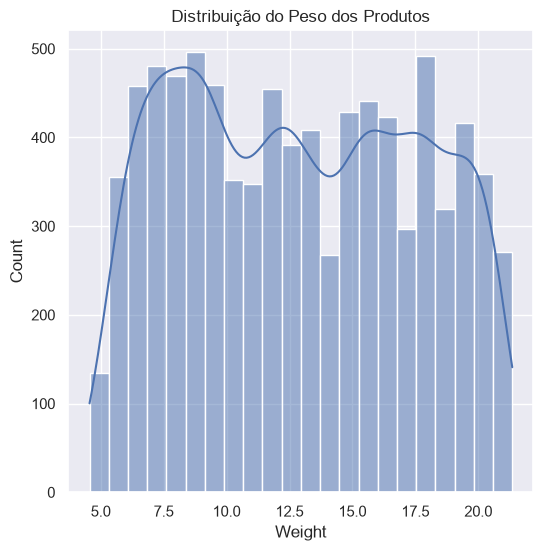

In [ ]:
# Distribuição do peso dos produtos para avaliar simetria e possíveis valores extremos
plt.figure(figsize=(6, 6))
sns.histplot(big_mart['Weight'], kde=True)
plt.title('Distribuição do Peso dos Produtos')
plt.show()

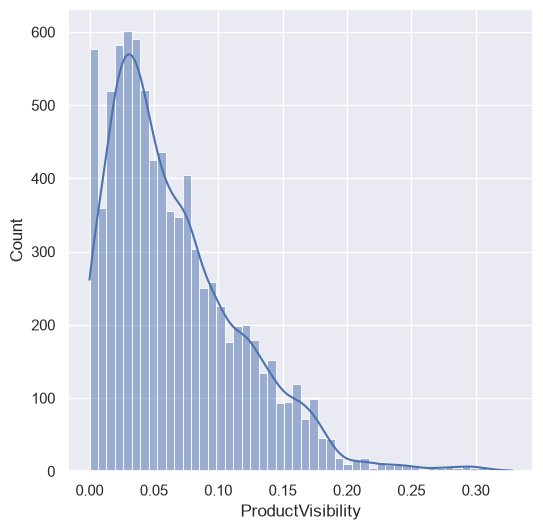

In [ ]:
# Distribuição da visibilidade do produto para entender o comportamento das categorias nas prateleiras
plt.figure(figsize=(6, 6))
sns.histplot(big_mart['ProductVisibility'], kde=True)
plt.title('Distribuição da Visibilidade do Produto')
plt.show()

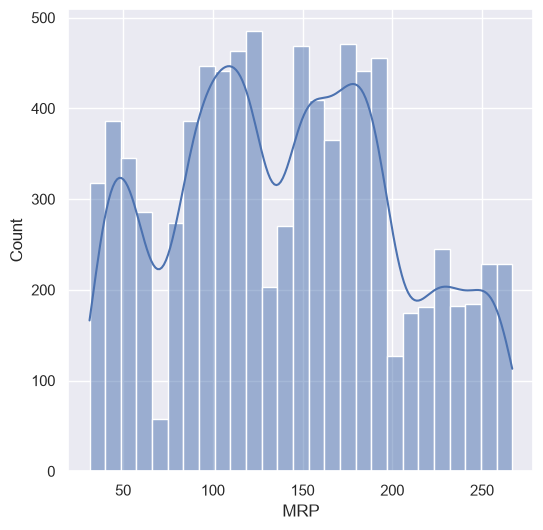

In [ ]:
# Distribuição do preço máximo de venda (MRP) para verificar a escala e possíveis assimetrias
plt.figure(figsize=(6, 6))
sns.histplot(big_mart['MRP'], kde=True)
plt.title('Distribuição do Preço Máximo de Venda (MRP)')
plt.show()

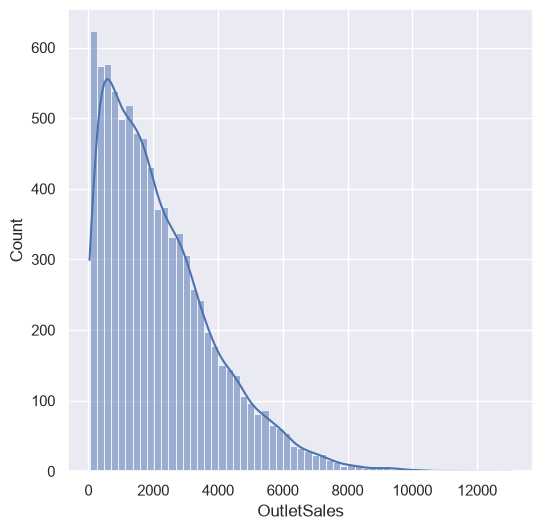

In [ ]:
# Distribuição da variável alvo para analisar o comportamento das vendas e a presença de valores extremos
plt.figure(figsize=(6, 6))
sns.histplot(big_mart['OutletSales'], kde=True)
plt.title('Distribuição das Vendas (OutletSales)')
plt.show()

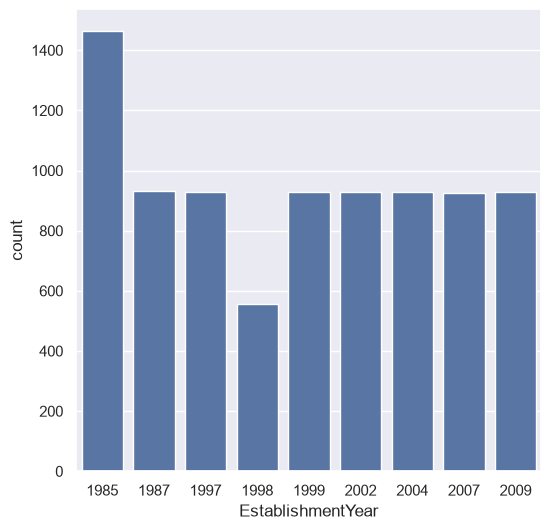

In [ ]:
# Frequência do ano de estabelecimento das lojas para verificar a distribuição temporal da base
plt.figure(figsize=(6, 6))
sns.countplot(x='EstablishmentYear', data=big_mart)
plt.title('Frequência por Ano de Estabelecimento da Loja')
plt.show()

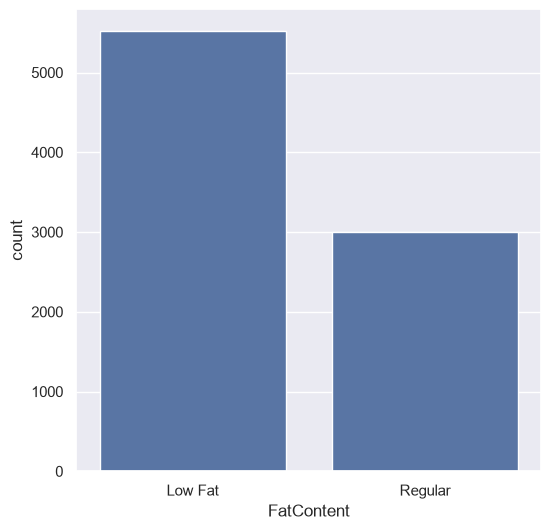

In [ ]:
# Frequência das categorias de gordura para validar a consistência da variável após o tratamento
plt.figure(figsize=(6, 6))
sns.countplot(x='FatContent', data=big_mart)
plt.title('Distribuição de FatContent')
plt.show()

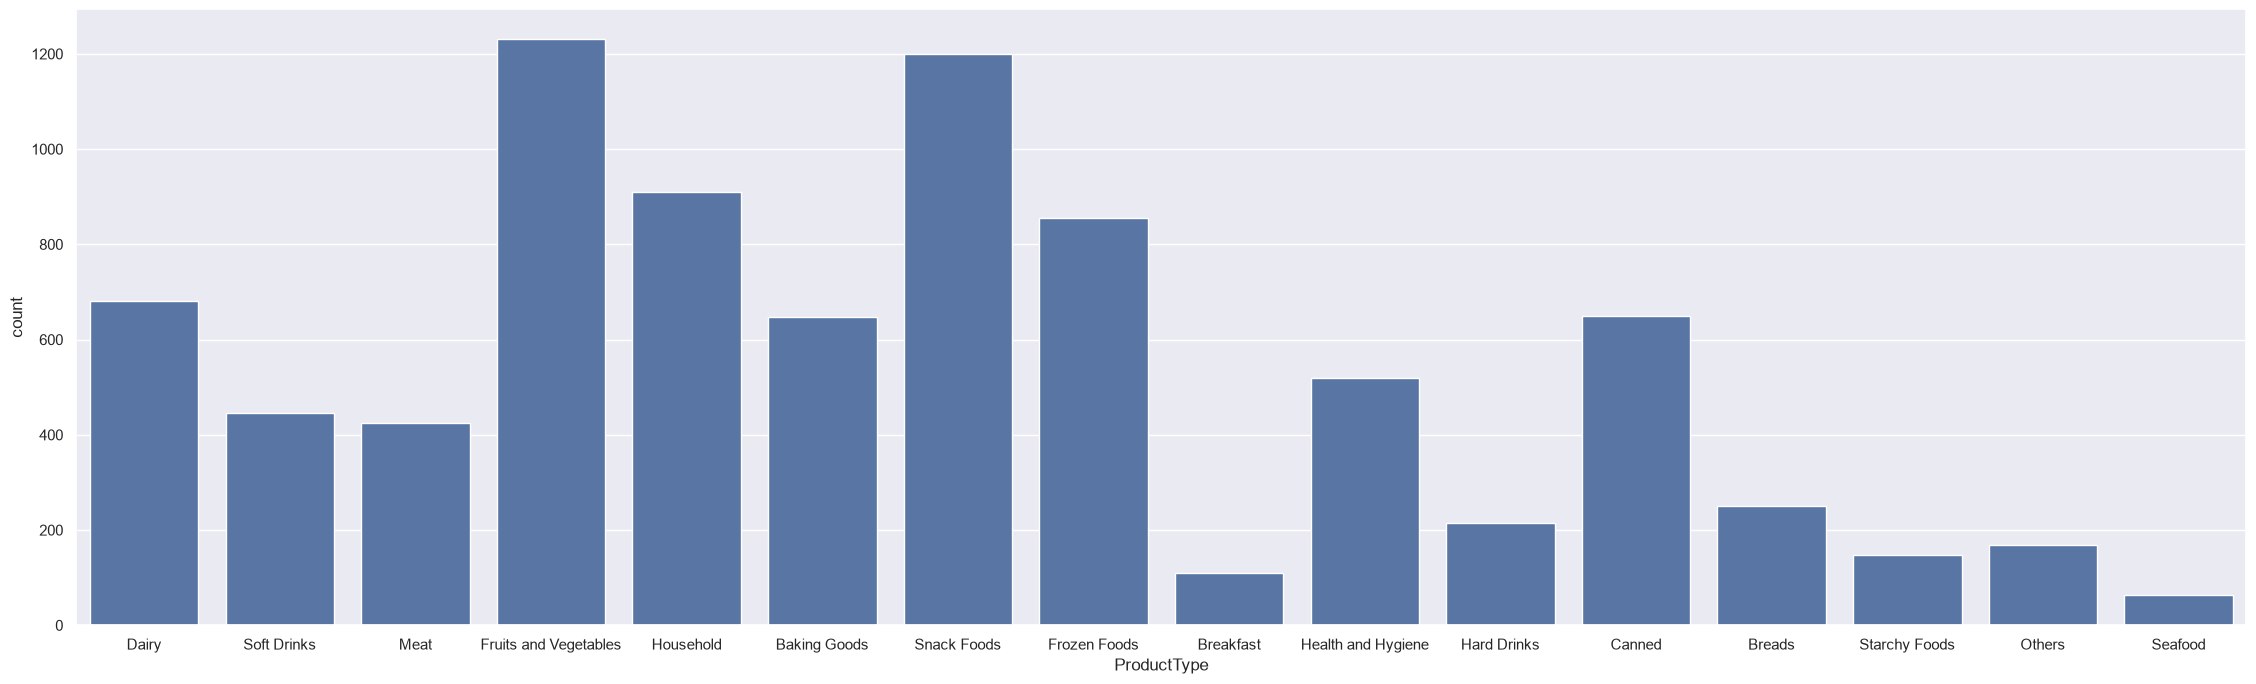

In [ ]:
# Frequência dos tipos de produto para identificar categorias mais recorrentes na base
plt.figure(figsize=(28, 8))
sns.countplot(x='ProductType', data=big_mart)
plt.title('Distribuição de ProductType')
plt.xticks(rotation=45, ha='right')
plt.show()

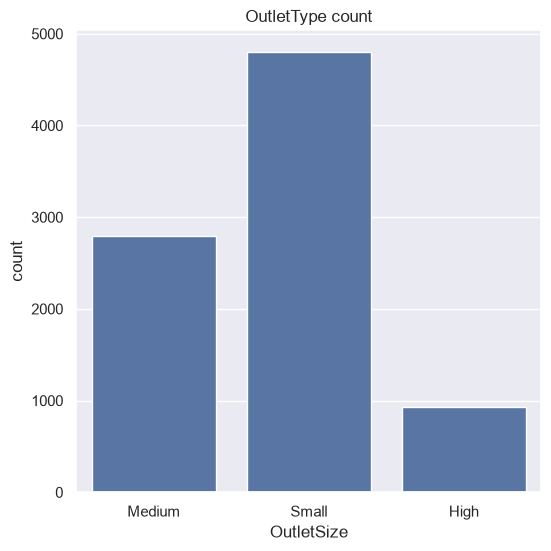

In [ ]:
# Frequência do tamanho das lojas para avaliar a composição da rede e a qualidade da imputação
plt.figure(figsize=(6, 6))
sns.countplot(x='OutletSize', data=big_mart)
plt.title('Distribuição de OutletSize')
plt.show()

---

## Próximos Passos

- **Feature Engineering**: Engenharia de features derivadas
- **Encoding de Variáveis Categóricas**: Label Encoding ou One-Hot Encoding
- **Normalização/Padronização**: Preparação para modelos de ML
- **Divisão Treino/Teste**: Preparação para modelagem
- **Modelagem Preditiva**: Treinar e avaliar XGBoost